# DeepScan — Custom CNN Built From Scratch (Colab T4 Safe)

**What changed vs the previous notebook:**

1. **No transfer learning / no pretrained backbone.** The old version used
   `MobileNetV2(weights='imagenet')`. Every weight in this model starts
   randomly initialized and is learned only from *your* dataset. There is no
   ImageNet backbone hiding in here — this is a genuine "from scratch" CNN.
2. **Crash-resistant on a T4:**
   - Mixed precision (`mixed_float16`) roughly halves GPU memory use.
   - Smaller default image size (128px) — a from-scratch CNN doesn't need
     224px inputs the way an ImageNet backbone does, and it cuts memory a lot.
   - Automatic **out-of-memory backoff**: if training hits a GPU OOM error,
     it halves the batch size, clears the session, and retries automatically
     instead of crashing the runtime.
   - Checkpoints save to **Google Drive**, not `/content` — `/content` is
     wiped if Colab disconnects, Drive isn't.
   - Robust video-frame extraction: corrupted/unreadable videos are skipped
     instead of stopping the whole run, and memory is freed periodically.
   - A per-epoch cleanup callback (`gc.collect()`) to fight the slow memory
     creep that's a common cause of long Colab sessions crashing partway
     through training.

**Label convention (unchanged):** `0 = Real`, `1 = Fake`.
**Preprocessing:** `x / 255.0` → `[0, 1]`.


In [1]:
import os, gc, random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU available:', gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print('Could not set memory growth:', e)
if gpus:
    print(f'Memory growth enabled on {len(gpus)} GPU(s)')

# Mixed precision roughly halves activation/gradient memory on a T4 and is
# one of the single biggest levers against an out-of-memory crash.
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision (mixed_float16) enabled')
except Exception as e:
    print('Could not enable mixed precision (continuing in float32):', e)


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled on 1 GPU(s)
Mixed precision (mixed_float16) enabled


In [2]:
import zipfile
from google.colab import drive

drive.mount('/content/drive')

ZIP_PATH   = '/content/drive/MyDrive/Dataset.zip'
EXTRACT_TO = '/content/Dataset'

# Idempotent extraction — if you re-run this cell (e.g. after a crash) it
# won't waste time/RAM re-extracting a dataset that's already on disk.
if not os.path.exists(EXTRACT_TO) or not os.listdir(EXTRACT_TO):
    print(f"Extracting '{ZIP_PATH}' to '{EXTRACT_TO}' ...")
    os.makedirs(EXTRACT_TO, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print('Extraction complete!')
else:
    print(f"'{EXTRACT_TO}' already has content — skipping extraction "
          f"(delete the folder first if you want to re-extract).")

print('\nFolder structure:')
for root, dirs, files_list in os.walk(EXTRACT_TO):
    depth = root.replace(EXTRACT_TO, '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    for f in files_list[:3]:
        print(f'{indent}  {f}')


Mounted at /content/drive
Extracting '/content/drive/MyDrive/Dataset.zip' to '/content/Dataset' ...
Extraction complete!

Folder structure:
Dataset/
  Dataset/
    Video/
    Image/


## Config

`IMG_SIZE` is lowered to **128** and `BATCH_SIZE` to **16** compared to the
original notebook. A from-scratch CNN doesn't need 224px inputs (that size
convention comes from ImageNet backbones like MobileNetV2), so shrinking it
saves a large amount of GPU memory for very little accuracy cost. Both are
still easy to bump back up if your T4 is coping fine.

Checkpoints and the final model are saved under **Google Drive**
(`DRIVE_OUT_DIR`) instead of `/content`, so a crashed/disconnected runtime
doesn't lose your trained weights.

In [3]:
IMG_SIZE   = 128       # was 224 — smaller input = much lower memory use
BATCH_SIZE = 16        # was 32 — starting point; auto-backoff will lower it
                       # further on its own if the GPU still runs out of memory
EPOCHS     = 15
MAX_VIDEOS = 500
FRAME_SKIP = 30
AUTOTUNE   = tf.data.AUTOTUNE

IMAGE_DIR  = '/content/Dataset/Dataset/Image'
VIDEO_REAL = '/content/Dataset/Dataset/Video/Real'
VIDEO_FAKE = '/content/Dataset/Dataset/Video/Fake'
FRAMES_DIR = '/content/Dataset/Dataset/frames'

# Google Drive, not /content -> survives a Colab disconnect/crash
DRIVE_OUT_DIR = '/content/drive/MyDrive/DeepfakeDetector'
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(DRIVE_OUT_DIR, 'deepfake_model_scratch_best.keras')
LAST_CKPT_PATH  = os.path.join(DRIVE_OUT_DIR, 'deepfake_model_scratch_last.keras')

print('Label convention: 0=Real  1=Fake')
print(f'Config ready | IMG:{IMG_SIZE} BATCH:{BATCH_SIZE} EPOCHS:{EPOCHS}')
print(f'Checkpoints will be saved to: {DRIVE_OUT_DIR}')


Label convention: 0=Real  1=Fake
Config ready | IMG:128 BATCH:16 EPOCHS:15
Checkpoints will be saved to: /content/drive/MyDrive/DeepfakeDetector


In [4]:
# -- IMAGE DATASET -----------------------------------------------------------
# Forces class order to ['Real', 'Fake'] so Real=0, Fake=1 everywhere.
def build_image_datasets(image_dir, img_size, batch_size):
    # Loads images from pre-split Train/Validation dirs. Real=0, Fake=1.
    train_path = os.path.join(image_dir, 'Train')
    val_path   = os.path.join(image_dir, 'Validation')

    common_args = dict(
        image_size  = (img_size, img_size),
        batch_size  = batch_size,
        class_names = ['Real', 'Fake'],
        seed        = SEED,
    )

    train_ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory=train_path, shuffle=True, **common_args)
    val_ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory=val_path, shuffle=False, **common_args)

    assert train_ds.class_names == ['Real', 'Fake'], \
        f'Class order wrong! Found {train_ds.class_names}'

    return train_ds, val_ds

print('Image dataset loader ready.')


Image dataset loader ready.


## Video frame extraction (robust)

Runs once regardless of batch size. Broken/corrupt video files are skipped
with a warning instead of stopping the whole notebook, and `gc.collect()`
is called periodically so OpenCV doesn't slowly build up RAM usage across
hundreds of videos.

In [5]:
import cv2

os.makedirs(FRAMES_DIR + '/0', exist_ok=True)  # Real
os.makedirs(FRAMES_DIR + '/1', exist_ok=True)  # Fake

def extract_frames_to_disk(real_folder, fake_folder,
                            max_videos=MAX_VIDEOS,
                            frame_skip=FRAME_SKIP,
                            img_size=IMG_SIZE):
    EXT   = ('.mp4', '.avi', '.mov', '.mkv')
    total = 0
    for folder, label in [(real_folder, 0), (fake_folder, 1)]:
        tag = 'Real' if label == 0 else 'Fake'
        if not os.path.isdir(folder):
            print(f'  [!] {tag} folder not found: {folder} -- skipping.')
            continue
        videos = sorted([v for v in os.listdir(folder)
                          if v.lower().endswith(EXT)])[:max_videos]
        print(f'  {tag} (label={label}): {len(videos)} videos ...')
        for i, video in enumerate(videos):
            cap = cv2.VideoCapture(os.path.join(folder, video))
            if not cap.isOpened():
                print(f'    [!] Could not open {video}, skipping.')
                cap.release()
                continue
            count = 0
            try:
                while True:
                    ret, frame = cap.read()
                    if not ret:
                        break
                    if count % frame_skip == 0:
                        try:
                            frame = cv2.resize(frame, (img_size, img_size))
                            save_path = f'{FRAMES_DIR}/{label}/v{i:04d}_f{count:06d}.jpg'
                            cv2.imwrite(save_path, frame)
                            total += 1
                        except cv2.error as e:
                            print(f'    [!] Frame error in {video} @ {count}: {e}')
                    count += 1
            except Exception as e:
                print(f'    [!] Error reading {video}: {e}')
            finally:
                cap.release()
            if i % 25 == 0:
                gc.collect()
        print(f'    Done. Total frames so far: {total}')
        gc.collect()
    print(f'All frames saved. Total: {total}')

already_extracted = (
    os.path.isdir(FRAMES_DIR + '/0') and os.listdir(FRAMES_DIR + '/0')
) or (
    os.path.isdir(FRAMES_DIR + '/1') and os.listdir(FRAMES_DIR + '/1')
)

if not already_extracted:
    print('Extracting video frames ...')
    extract_frames_to_disk(VIDEO_REAL, VIDEO_FAKE)
else:
    print('Frames already extracted -- skipping (delete the frames dir to redo).')


Extracting video frames ...
  Real (label=0): 500 videos ...
    Done. Total frames so far: 8976
  Fake (label=1): 500 videos ...
    Done. Total frames so far: 17952
All frames saved. Total: 17952


In [6]:
# -- BUILD FULL PIPELINE (parameterized by batch_size so the OOM backoff
#    below can rebuild it at a smaller batch size if needed) ----------------
def prepare_pipelines(img_size, batch_size):
    image_train_ds, image_val_ds = build_image_datasets(IMAGE_DIR, img_size, batch_size)

    video_ds_full = tf.keras.preprocessing.image_dataset_from_directory(
        FRAMES_DIR,
        image_size = (img_size, img_size),
        batch_size = batch_size,
        shuffle    = True,
        seed       = SEED,
        label_mode = 'int',
    )
    assert video_ds_full.class_names == ['0', '1'], \
        f'Video class order wrong! Found {video_ds_full.class_names}'

    def normalize(ds):
        return (ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, tf.cast(y, tf.int32)),
                        num_parallel_calls=AUTOTUNE)
                   .prefetch(AUTOTUNE))

    video_ds  = normalize(video_ds_full)
    train_ds  = normalize(image_train_ds).concatenate(video_ds)
    val_ds    = normalize(image_val_ds)
    return train_ds, val_ds

print('Pipeline builder ready. (0=Real, 1=Fake, x/255 normalisation)')


Pipeline builder ready. (0=Real, 1=Fake, x/255 normalisation)


## Model — built entirely from scratch

No pretrained backbone, no ImageNet weights. Every convolution filter here
starts randomly initialized and is learned only from this dataset. The final
`Dense` layer is forced to `float32` even under mixed precision, since
sigmoid + binary cross-entropy can get numerically unstable in `float16`.

In [7]:
from tensorflow.keras import layers, Model, regularizers

def build_model(img_size):
    inputs = tf.keras.Input(shape=(img_size, img_size, 3))

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    output = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    model = Model(inputs, output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return model

print('Model builder ready.')


Model builder ready.


## Training with automatic out-of-memory backoff

This is the main anti-crash mechanism. If `model.fit` throws a GPU
`ResourceExhaustedError` (a T4 out-of-memory error — the most common reason
this kind of notebook crashes), the code below:

1. Clears the Keras session and runs garbage collection.
2. Halves the batch size.
3. Rebuilds the data pipeline and model at the smaller batch size.
4. Retries — down to a minimum batch size of 2.

If it still fails at the minimum batch size, it raises a clear error telling
you to lower `IMG_SIZE` instead.

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

class MemoryCleanup(Callback):
    # Runs gc.collect() after every epoch to fight the slow memory creep
    # that's a common cause of long Colab sessions crashing partway through
    # training.
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

def make_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
        ModelCheckpoint(LAST_CKPT_PATH, save_best_only=False, verbose=1),
        ModelCheckpoint(BEST_MODEL_PATH, save_best_only=True, monitor='val_accuracy', verbose=1),
        MemoryCleanup(),
    ]

def run_training(img_size, batch_size, epochs, min_batch=2):
    bs = batch_size
    while bs >= min_batch:
        try:
            print(f'\n===== Attempting training with batch_size={bs} =====')
            tf.keras.backend.clear_session()
            gc.collect()
            train_ds, val_ds = prepare_pipelines(img_size, bs)
            model = build_model(img_size)
            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                callbacks=make_callbacks(),
                verbose=1,
            )
            return model, history, val_ds, bs
        except tf.errors.ResourceExhaustedError as e:
            print(f'[!] GPU out of memory at batch_size={bs}.')
            print(f'    {e}')
            bs = bs // 2
            tf.keras.backend.clear_session()
            gc.collect()
            print(f'    Retrying with batch_size={bs} ...')
    raise RuntimeError(
        'Training still runs out of memory even at the minimum batch size. '
        'Try lowering IMG_SIZE (e.g. to 96) and re-running from the config cell.'
    )

model, history, val_ds, used_batch_size = run_training(IMG_SIZE, BATCH_SIZE, EPOCHS)
print(f'\nTraining finished successfully with batch_size={used_batch_size}')



===== Attempting training with batch_size=16 =====
Found 140002 files belonging to 2 classes.
Found 39428 files belonging to 2 classes.
Found 17952 files belonging to 2 classes.
Epoch 1/15
9872/9873 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8017 - auc: 0.8813 - loss: 0.4194 - precision: 0.8138 - recall: 0.7770
Epoch 1: saving model to /content/drive/MyDrive/DeepfakeDetector/deepfake_model_scratch_last.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepfakeDetector/deepfake_model_scratch_last.keras

Epoch 1: val_accuracy improved from None to 0.59389, saving model to /content/drive/MyDrive/DeepfakeDetector/deepfake_model_scratch_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepfakeDetector/deepfake_model_scratch_best.keras
9873/9873 ━━━━━━━━━━━━━━━━━━━━ 227s 22ms/step - accuracy: 0.8399 - auc: 0.9353 - loss: 0.3396 - precision: 0.8455 - recall: 0.8318 - val_accuracy: 0.5939 - val_auc: 0.7446 - val_loss: 0.6568 - val_precision: 0.5551 - val

In [9]:
print('\n===== FINAL EVALUATION =====')
results   = model.evaluate(val_ds, verbose=1)
names     = model.metrics_names
loss      = results[0]
accuracy  = results[1]
auc       = results[2]
precision = results[3]
recall    = results[4]
f1        = 2 * (precision * recall) / (precision + recall + 1e-8)

print('\n--- Results ---')
for n, v in zip(names, results):
    print(f'  {n:12s}: {v:.4f}')
print(f'  {"F1 Score":12s}: {f1:.4f}')
print(f'\nFinal Accuracy : {accuracy*100:.2f}%')
print(f'AUC Score      : {auc:.4f}')
print(f'F1 Score       : {f1:.4f}')



===== FINAL EVALUATION =====
2465/2465 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.8126 - auc: 0.9068 - loss: 0.4507 - precision: 0.7619 - recall: 0.9073

--- Results ---
  loss        : 0.4507
  compile_metrics: 0.8126
  F1 Score    : 0.8283

Final Accuracy : 81.26%
AUC Score      : 0.9068
F1 Score       : 0.8283


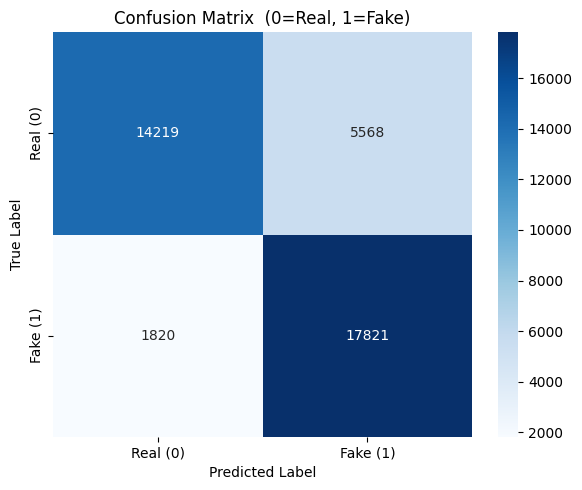


Classification Report:
              precision    recall  f1-score   support

        Real       0.89      0.72      0.79     19787
        Fake       0.76      0.91      0.83     19641

    accuracy                           0.81     39428
   macro avg       0.82      0.81      0.81     39428
weighted avg       0.82      0.81      0.81     39428


=== VERIFY MODEL DIRECTION ===
  [OK] True=Real  sigmoid=0.1906  predicted=Real
  [X] True=Real  sigmoid=0.7847  predicted=Fake
  [X] True=Real  sigmoid=0.8816  predicted=Fake
  [OK] True=Real  sigmoid=0.1000  predicted=Real
  [X] True=Real  sigmoid=0.5429  predicted=Fake


In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_true, y_pred_prob = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred_prob.extend(preds.flatten().tolist())
    y_true.extend(labels.numpy().tolist())

y_pred = [1 if p >= 0.5 else 0 for p in y_pred_prob]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
plt.title('Confusion Matrix  (0=Real, 1=Fake)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

print('\n=== VERIFY MODEL DIRECTION ===')
sample_images, sample_labels = next(iter(val_ds))
sample_preds = model.predict(sample_images[:5], verbose=0).flatten()
for pred, true in zip(sample_preds, sample_labels[:5].numpy()):
    true_str = 'Real' if true == 0 else 'Fake'
    pred_str = 'Fake' if pred >= 0.5 else 'Real'
    ok = 'OK' if true_str == pred_str else 'X'
    print(f'  [{ok}] True={true_str}  sigmoid={pred:.4f}  predicted={pred_str}')


In [11]:
# -- SAVE & DOWNLOAD ----------------------------------------------------------
# BEST_MODEL_PATH already holds the best checkpoint (saved to Drive during
# training), so this just confirms it and offers a local download.
print(f'Best model already saved to Drive at: {BEST_MODEL_PATH}')
print('Label convention: 0=Real  1=Fake')
print('Preprocessing  : x/255.0  [0,1]')
print(f'Trained at batch_size={used_batch_size}, IMG_SIZE={IMG_SIZE}')

try:
    from google.colab import files
    files.download(BEST_MODEL_PATH)
except Exception as e:
    print(f'Local download not available ({e}). '
          f'The model is safely stored on Google Drive at the path above.')


Best model already saved to Drive at: /content/drive/MyDrive/DeepfakeDetector/deepfake_model_scratch_best.keras
Label convention: 0=Real  1=Fake
Preprocessing  : x/255.0  [0,1]
Trained at batch_size=16, IMG_SIZE=128


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>